<a href="https://colab.research.google.com/github/AVK48/AI-ML-JOURNEY/blob/AVK48-main/IMDb_Top_250_Movie_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_csv("/content/ToP 250 movies on imdb in 2026.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   250 non-null    object 
 1   url                  250 non-null    object 
 2   primaryTitle         250 non-null    object 
 3   originalTitle        250 non-null    object 
 4   type                 250 non-null    object 
 5   description          250 non-null    object 
 6   primaryImage         250 non-null    object 
 7   thumbnails           250 non-null    object 
 8   trailer              243 non-null    object 
 9   contentRating        244 non-null    object 
 10  startYear            250 non-null    int64  
 11  endYear              0 non-null      float64
 12  releaseDate          249 non-null    object 
 13  interests            250 non-null    object 
 14  countriesOfOrigin    250 non-null    object 
 15  externalLinks        250 non-null    obj

In [4]:
df1 = df

In [5]:
df1 = df1.drop(['endYear','thumbnails','trailer','url','description','primaryTitle','type','id','externalLinks','interests','primaryImage','filmingLocations','productionCompanies','releaseDate'],axis =1, errors='ignore')

In [6]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   originalTitle      250 non-null    object 
 1   contentRating      244 non-null    object 
 2   startYear          250 non-null    int64  
 3   countriesOfOrigin  250 non-null    object 
 4   spokenLanguages    250 non-null    object 
 5   budget             226 non-null    float64
 6   grossWorldwide     246 non-null    float64
 7   genres             250 non-null    object 
 8   isAdult            250 non-null    bool   
 9   runtimeMinutes     250 non-null    int64  
 10  averageRating      250 non-null    float64
 11  numVotes           250 non-null    int64  
 12  metascore          232 non-null    float64
dtypes: bool(1), float64(4), int64(3), object(5)
memory usage: 23.8+ KB


In [7]:
df1.isnull().sum()

,0
originalTitle,0
contentRating,6
startYear,0
countriesOfOrigin,0
spokenLanguages,0
budget,24
grossWorldwide,4
genres,0
isAdult,0
runtimeMinutes,0


In [8]:
df1.head(10)

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],25000000.0,2.942491e+07,['Drama'],False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6000000.0,2.509334e+08,"['Crime', 'Drama']",False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],185000000.0,1.008480e+09,"['Crime', 'Thriller']",False,152,9.1,3204629,85.0
3,The Godfather Part II,R,1974,['US'],"['en', 'it', 'es', 'la']",13000000.0,4.820954e+07,"['Crime', 'Drama']",False,202,9.0,1505420,90.0
4,The Lord of the Rings: The Return of the King,PG-13,2003,"['NZ', 'US']",['en'],94000000.0,1.149454e+09,"['Adventure', 'Drama', 'Fantasy']",False,201,9.0,2181632,94.0
5,12 Angry Men,Approved,1957,['US'],['en'],350000.0,1.316800e+04,"['Crime', 'Drama']",False,96,9.0,996035,97.0
6,Schindler's List,R,1993,['US'],"['en', 'he', 'de', 'pl', 'la']",22000000.0,3.221612e+08,"['Biography', 'Drama', 'History']",False,195,9.0,1595817,95.0
7,The Lord of the Rings: The Fellowship of the Ring,PG-13,2001,"['NZ', 'US', 'GB']",['en'],93000000.0,8.975396e+08,"['Adventure', 'Drama', 'Fantasy']",False,178,8.9,2224790,92.0
8,Pulp Fiction,R,1994,['US'],"['en', 'es', 'fr']",8000000.0,2.139288e+08,"['Crime', 'Drama']",False,154,8.8,2455116,95.0
9,"Il buono, il brutto, il cattivo",R,1966,"['IT', 'ES', 'US']","['en', 'it']",1200000.0,2.528018e+07,"['Adventure', 'Drama', 'Western']",False,178,8.8,896337,90.0


In [9]:
exdf= df1.explode('genres')
exdf

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],2.500000e+07,2.942491e+07,['Drama'],False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6.000000e+06,2.509334e+08,"['Crime', 'Drama']",False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],1.850000e+08,1.008480e+09,"['Crime', 'Thriller']",False,152,9.1,3204629,85.0
3,The Godfather Part II,R,1974,['US'],"['en', 'it', 'es', 'la']",1.300000e+07,4.820954e+07,"['Crime', 'Drama']",False,202,9.0,1505420,90.0
4,The Lord of the Rings: The Return of the King,PG-13,2003,"['NZ', 'US']",['en'],9.400000e+07,1.149454e+09,"['Adventure', 'Drama', 'Fantasy']",False,201,9.0,2181632,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,The Wizard of Oz,G,1939,['US'],['en'],2.777000e+06,2.563767e+07,"['Adventure', 'Family', 'Fantasy']",False,102,8.1,470727,92.0
246,La battaglia di Algeri,Not Rated,1966,"['IT', 'DZ']","['ar', 'fr', 'en', 'es']",8.000000e+05,9.634740e+05,"['Drama', 'War']",False,121,8.1,76541,96.0
247,Babam ve Oglum,Not Rated,2005,['TR'],['tr'],NaN,1.861300e+07,['Drama'],False,112,8.2,101710,NaN
248,La passion de Jeanne d'Arc,Passed,1928,['FR'],"['fr', 'la']",NaN,2.273100e+04,"['Biography', 'Drama', 'History']",False,114,8.1,68877,98.0


In [10]:
display(exdf.head())

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],25000000.0,2.942491e+07,['Drama'],False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6000000.0,2.509334e+08,"['Crime', 'Drama']",False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],185000000.0,1.008480e+09,"['Crime', 'Thriller']",False,152,9.1,3204629,85.0
3,The Godfather Part II,R,1974,['US'],"['en', 'it', 'es', 'la']",13000000.0,4.820954e+07,"['Crime', 'Drama']",False,202,9.0,1505420,90.0
4,The Lord of the Rings: The Return of the King,PG-13,2003,"['NZ', 'US']",['en'],94000000.0,1.149454e+09,"['Adventure', 'Drama', 'Fantasy']",False,201,9.0,2181632,94.0


In [11]:
exdf['genres'].value_counts()

,count
genres,
['Drama'],15
"['Crime', 'Drama']",14
"['Drama', 'War']",10
"['Crime', 'Drama', 'Mystery']",9
"['Adventure', 'Animation', 'Comedy']",9
...,...
['Comedy'],1
"['Drama', 'Film-Noir', 'Mystery']",1
"['Drama', 'Fantasy']",1


In [12]:
import ast

df1['genres'] = df1['genres'].apply(ast.literal_eval)
exdf = df1.explode('genres')

In [13]:
display(exdf.head())

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],25000000.0,2.942491e+07,Drama,False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6000000.0,2.509334e+08,Crime,False,175,9.2,2244201,100.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6000000.0,2.509334e+08,Drama,False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],185000000.0,1.008480e+09,Crime,False,152,9.1,3204629,85.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],185000000.0,1.008480e+09,Thriller,False,152,9.1,3204629,85.0


In [14]:
genre_counts =exdf['genres'].value_counts()
genre_counts

,count
genres,
Drama,179
Adventure,66
Crime,52
Comedy,42
Action,42
Mystery,31
Thriller,30
Animation,28
Biography,27


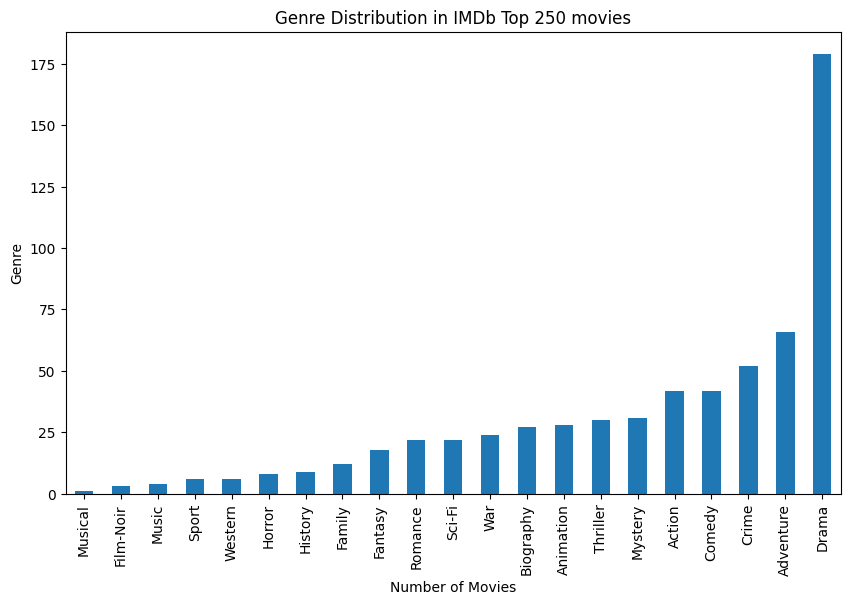

Dominant Genre: Drama
Number of Movies: 179


In [15]:
plt.figure(figsize=(10,6))
genre_counts.plot(kind='bar')
plt.title('Genre Distribution in IMDb Top 250 movies')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.gca().invert_xaxis()
plt.show()

print("Dominant Genre:",genre_counts.idxmax())
print("Number of Movies:",genre_counts.max())

In [16]:
#inspecting the langauges
df1

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],2.500000e+07,2.942491e+07,[Drama],False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6.000000e+06,2.509334e+08,"[Crime, Drama]",False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],1.850000e+08,1.008480e+09,"[Crime, Thriller]",False,152,9.1,3204629,85.0
3,The Godfather Part II,R,1974,['US'],"['en', 'it', 'es', 'la']",1.300000e+07,4.820954e+07,"[Crime, Drama]",False,202,9.0,1505420,90.0
4,The Lord of the Rings: The Return of the King,PG-13,2003,"['NZ', 'US']",['en'],9.400000e+07,1.149454e+09,"[Adventure, Drama, Fantasy]",False,201,9.0,2181632,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,The Wizard of Oz,G,1939,['US'],['en'],2.777000e+06,2.563767e+07,"[Adventure, Family, Fantasy]",False,102,8.1,470727,92.0
246,La battaglia di Algeri,Not Rated,1966,"['IT', 'DZ']","['ar', 'fr', 'en', 'es']",8.000000e+05,9.634740e+05,"[Drama, War]",False,121,8.1,76541,96.0
247,Babam ve Oglum,Not Rated,2005,['TR'],['tr'],NaN,1.861300e+07,[Drama],False,112,8.2,101710,NaN
248,La passion de Jeanne d'Arc,Passed,1928,['FR'],"['fr', 'la']",NaN,2.273100e+04,"[Biography, Drama, History]",False,114,8.1,68877,98.0


In [17]:
exdf['spokenLanguages'].value_counts()

,count
spokenLanguages,
['en'],224
['ja'],42
"['en', 'es']",42
"['en', 'fr']",29
"['en', 'la']",9
...,...
"['ja', 'la', 'en', 'fr']",1
"['ar', 'am']",1
"['en', 'de', 'el', 'la', 'it']",1


In [18]:
#separating the langauges
languages_count = (exdf['spokenLanguages'].str.split().explode().str.strip().value_counts())
languages_count

,count
spokenLanguages,
"['en',",270
['en'],224
'fr'],65
"'de',",63
'es'],61
...,...
"'el',",2
"'ne',",1
'am'],1


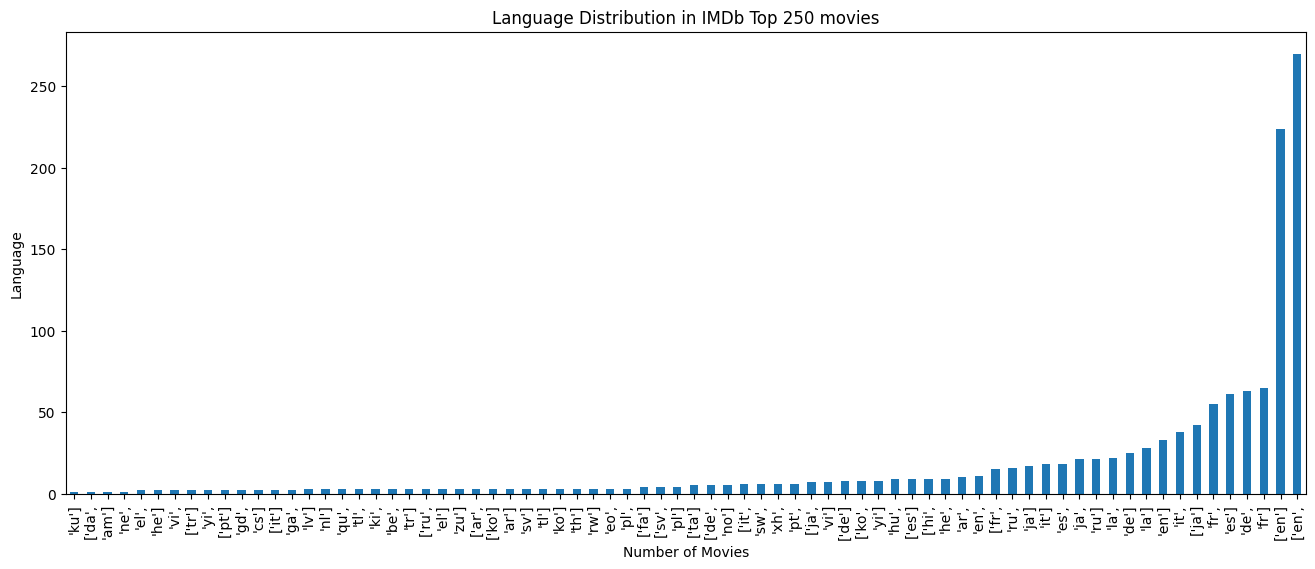

Most represented Language: ['en',
Number of Movies: 270


In [19]:
plt.figure(figsize=(16,6))
languages_count.plot(kind='bar')
plt.title('Language Distribution in IMDb Top 250 movies')
plt.xlabel('Number of Movies')
plt.ylabel('Language')
plt.gca().invert_xaxis()
plt.show()

print("Most represented Language:",languages_count.idxmax())
print("Number of Movies:",languages_count.max())

DO HIGHLY RATED MOVIES  ALSO HAVE MORE VOTES?

In [20]:
df1

,originalTitle,contentRating,startYear,countriesOfOrigin,spokenLanguages,budget,grossWorldwide,genres,isAdult,runtimeMinutes,averageRating,numVotes,metascore
0,The Shawshank Redemption,R,1994,['US'],['en'],2.500000e+07,2.942491e+07,[Drama],False,142,9.3,3219026,82.0
1,The Godfather,R,1972,['US'],"['en', 'it', 'la']",6.000000e+06,2.509334e+08,"[Crime, Drama]",False,175,9.2,2244201,100.0
2,The Dark Knight,PG-13,2008,"['US', 'GB']",['en'],1.850000e+08,1.008480e+09,"[Crime, Thriller]",False,152,9.1,3204629,85.0
3,The Godfather Part II,R,1974,['US'],"['en', 'it', 'es', 'la']",1.300000e+07,4.820954e+07,"[Crime, Drama]",False,202,9.0,1505420,90.0
4,The Lord of the Rings: The Return of the King,PG-13,2003,"['NZ', 'US']",['en'],9.400000e+07,1.149454e+09,"[Adventure, Drama, Fantasy]",False,201,9.0,2181632,94.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,The Wizard of Oz,G,1939,['US'],['en'],2.777000e+06,2.563767e+07,"[Adventure, Family, Fantasy]",False,102,8.1,470727,92.0
246,La battaglia di Algeri,Not Rated,1966,"['IT', 'DZ']","['ar', 'fr', 'en', 'es']",8.000000e+05,9.634740e+05,"[Drama, War]",False,121,8.1,76541,96.0
247,Babam ve Oglum,Not Rated,2005,['TR'],['tr'],NaN,1.861300e+07,[Drama],False,112,8.2,101710,NaN
248,La passion de Jeanne d'Arc,Passed,1928,['FR'],"['fr', 'la']",NaN,2.273100e+04,"[Biography, Drama, History]",False,114,8.1,68877,98.0


In [21]:
exdf[['averageRating', 'numVotes']].head()

,averageRating,numVotes
0,9.3,3219026
1,9.2,2244201
1,9.2,2244201
2,9.1,3204629
2,9.1,3204629


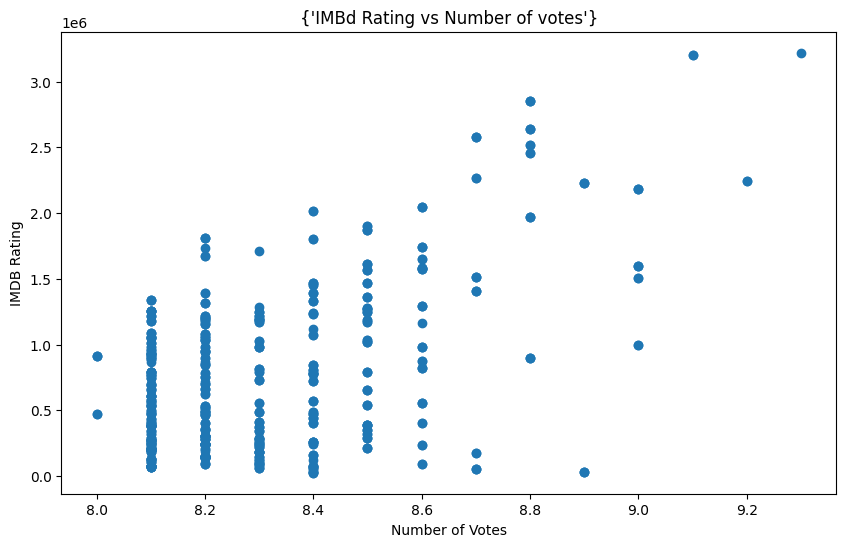

In [22]:
plt.figure(figsize=(10,6))
plt.scatter(exdf['averageRating'],exdf['numVotes'])
plt.title({"IMBd Rating vs Number of votes"})
plt.xlabel('Number of Votes')
plt.ylabel('IMDB Rating')
plt.show()

In [23]:
np.log1p(exdf['numVotes'])

,numVotes
0,14.984590
1,14.623861
1,14.623861
2,14.980107
2,14.980107
...,...
248,11.140092
248,11.140092
249,12.238840
249,12.238840


In [24]:
exdf[['averageRating', 'numVotes']].head()

,averageRating,numVotes
0,9.3,3219026
1,9.2,2244201
1,9.2,2244201
2,9.1,3204629
2,9.1,3204629
